In [2]:
# General imports
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy import integrate
from copy import deepcopy

# cloelib imports
from cloelib.cosmology.camb_cosmology import CAMBBackground, CAMBLinearPerturbations, CAMBNonLinearPerturbations
from cloelib.cosmology.HMcode2020Emu_cosmology import HMemuLinearPerturbations, HMemuNonLinearPerturbations
from cloelib.observables.photo import ShearTracer, PositionsTracer
from cloelib.summary_statistics.angular_two_point import AngularTwoPoint
from cloelib.summary_statistics.angular_correlation_function_wigner import AngularCorrelationFunctionWigner

# Beyond LCDM modules
# Linear boost from MGrowth 
from cloelib.cosmology.MGrowth_cosmology import MGrowthLinearPerturbations 
# Tabulated boost from simulations
from cloelib.cosmology.TabulatedBoost_cosmology import TabulatedNonlinearBoost, TabulatedBoostedPerturbations
# Halo model reaction boost 
from cloelib.cosmology.ReACTEmu_cosmology import MGemuNonlinearBoost, BoostedPerturbations

import euclidlib as el

# Plot style
import seaborn as sns
sns.set_theme(style="ticks")
sns.set_palette(sns.color_palette("Paired"))

plt.rc('xtick',labelsize=20)
plt.rc('ytick',labelsize=20)
plt.rc('font',size=20)
plt.rc('axes', titlesize=25)
plt.rc('axes', labelsize=20)
plt.rc('lines', linewidth=3)
plt.rc('lines', markersize=6)
plt.rc('legend', fontsize=14)

/Users/s2265800/miniforge3/envs/cloe-org-env-v2026.1/lib/python3.12/site-packages/MGEmu


In [3]:
#### LCDM perturbations ####

# DAKAR 2 baseline cosmology 
H0=67.66 
Omega_m0 = 0.311049
Omega_b0 = 0.04897468161869667 
Omega_cdm0 = Omega_m0-Omega_b0 
Omega_k0 = 0.0 
ns = 0.9665 
As = 2e-9
mnu = 0.00001
N_mnu = 1

# Set to LCDM as the boost is taken wrt to LCDM 
w0  = -1
wa  = 0.0

zs = np.linspace(1e-4, 3, 100)

# Load background LCDM cosmology 
lcdm_background = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0, wa=wa, 
                               gamma_MG=0.0)


linear_perturbations_emu = HMemuLinearPerturbations(lcdm_background, zs)
nonlinear_perturbations_emu = HMemuNonLinearPerturbations(lcdm_background, linear_perturbations_emu, zs, log10TAGN=7.8)

In [4]:
ds_snaps_0 = np.genfromtxt('dakar/DST_m09_m02/rspace_DM_Pk_snap_0.txt')
k = ds_snaps_0[:, 0]
nk = len(k)
ds_boosts = np.zeros((nk, 19))
ds_boosts[:, 0] = k
for i in range(18):
    ds_snaps = np.genfromtxt('dakar/DST_m09_m02/rspace_DM_Pk_snap_'+str(i)+'.txt')
    lcdm_snaps = np.genfromtxt('dakar/LCDM/rspace_DM_Pk_snap_'+str(i)+'.txt')
    boost = ds_snaps[:, 1]/lcdm_snaps[:, 1]
    ds_boosts[:, i+1] = boost

In [19]:
np.savetxt('dakar/m09_m02_boosts.txt',[ds_boosts_i for ds_boosts_i in ds_boosts])

In [5]:
# Paths to the boost tabulated data - run cosmology/TabulatedBoost.ipynb to download the data 
boost_table  = "dakar/m09_m02_boosts.txt"
#xi = 100; w0ds  = -0.9502; wads  = 0.0975;#  m095_p01_boosts
#xi = 100; w0ds  = -1.1001; wads  = 0.0966;#  m11_p01_boosts
xi = 100; w0ds  = -0.9001; wads  = -0.2025;#  m09_m02_boosts
# xi = 100; w0ds  = -0.9001; wads  = -0.1024;#  m09_m01_boosts

# Load background LCDM cosmology 
cpl_background = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0ds, wa=wads, 
                               gamma_MG=0.0)


linear_perturbations_emu_cpl = HMemuLinearPerturbations(cpl_background, zs)

In [6]:
#### Tabulated boosted perturbations ####


# Tabulated redshifts (corresponding the columns in the boost table)
z_cols = [3.017980, 2.479559, 2.161320, 2.013288, 1.609499, 1.259818, 1.000000, 0.823800, 0.677100, 0.552300, 0.444200, 0.349200, 0.264800, 0.188900, 0.120200, 0.057540, 0.000031, 0.0]


mg_boost_tab = TabulatedNonlinearBoost(lcdm_background,linear_perturbations_emu, zs, boost_table, z_cols, high_z_policy='freeze')
boost_interp_tab = mg_boost_tab.MGboost_interp
# Apply the nonlinear boost to HMCode and CAMB
boosted_perturbations_hmc_tab = TabulatedBoostedPerturbations(linear_perturbations_emu_cpl, nonlinear_perturbations_emu, boost_interp_tab)

In [7]:
#### Halo model reaction and linear boosted perturbations ####
gravity_model = 'ds'

# Provide all expected keys, with harmless defaults for unused ones
mgpars = {
    "xi": xi,          # Used for all DS cases
}

# Load background w0waCDM cosmology 
w0wa_background = CAMBBackground(H0=H0, Omega_b0=Omega_b0, Omega_cdm0=Omega_cdm0, 
                               Omega_k0=Omega_k0,
                               As=As, ns=ns, mnu=mnu, N_mnu=N_mnu, w0=w0ds, wa=wads, 
                               gamma_MG=0.0)
# MGrowth linear perturbations 
boosted_perturbations_hmc_mgrowth = MGrowthLinearPerturbations(w0wa_background, linear_perturbations_emu_cpl, gravity_model, mgpars)

mg_boost_react = MGemuNonlinearBoost(w0wa_background,boosted_perturbations_hmc_mgrowth, zs, gravity_model, mgpars)  #, high_z_policy='one')
boost_interp_react = mg_boost_react.MGboost_interp
# Apply the nonlinear boost to HMCode and CAMB
boosted_perturbations_hmc_react = BoostedPerturbations(boosted_perturbations_hmc_mgrowth, nonlinear_perturbations_emu, boost_interp_react)



Loading nonlinear emulator...
Nonlinear emulator loaded in memory.


In [8]:
data_path = "TR1_data/"
# Get n(z)
z_nz_pos, nz_pos = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_GC_C2020_sel_pv.fits')
z_nz_she, nz_she = el.phz.redshift_distributions(data_path+'TR1_v1_Nz_WL_C2020_sel_pv.fits')


# Normalize and resample n(z) for both position and shear
myz = np.linspace(1e-4, 3.0, 100)
def normalize_and_resample(nz_dict, z_grid, z_target):
    nz_array = np.vstack([nz / integrate.trapezoid(nz, z_grid) for nz in nz_dict.values()])
    return np.array([np.interp(z_target, z_grid, nz) for nz in nz_array])

my_dndz_pos_norm = normalize_and_resample(nz_pos, z_nz_pos, myz)
my_dndz_she_norm = normalize_and_resample(nz_she, z_nz_she, myz)

In [9]:
full_cov=np.load(data_path+'covariance_Gauss_Euclid_DR1_brighter_cut_1589_TR1_2D.npz')['Gauss']

In [11]:
fiducial_nuisance = {
    # Intrinsic alignment
    'AIA': 0.16, 'EtaIA': 1.66, 'CIA': 0.0134,
    # Galaxy bias (poly coefficients)
    'b1_photo_poly0': 1.33291, 'b1_photo_poly1': -0.72414, 
    'b1_photo_poly2': 1.0183, 'b1_photo_poly3': -0.14913,
    # Magnification bias (per bin)
    'magnification_bias_1': 0.0, 'magnification_bias_2': 0.0,
    'magnification_bias_3': 0.0, 'magnification_bias_4': 0.0,
    'magnification_bias_5': 0.0, 'magnification_bias_6': 0.0,
    # Redshift errors (positions)
    'dz_pos_1': 0.0, 'dz_pos_2': 0.0, 'dz_pos_3': 0.0, 
    'dz_pos_4': 0.0, 'dz_pos_5': 0.0, 'dz_pos_6': 0.0,
    # Multiplicative shear bias
    'multiplicative_bias_1': 0.0, 'multiplicative_bias_2': 0.0,
    'multiplicative_bias_3': 0.0, 'multiplicative_bias_4': 0.0,
    'multiplicative_bias_5': 0.0, 'multiplicative_bias_6': 0.0,
    # Redshift errors (shear)
    'dz_shear_1': 0.0, 'dz_shear_2': 0.0, 'dz_shear_3': 0.0,
    'dz_shear_4': 0.0, 'dz_shear_5': 0.0, 'dz_shear_6': 0.0,
    'width_pos_1': 1.0, 'width_pos_2': 1.0,
    'width_pos_3': 1.0, 'width_pos_4': 1.0,
    'width_pos_5': 1.0, 'width_pos_6': 1.0,
    'width_shear_1': 1.0, 'width_shear_2': 1.0,
    'width_shear_3': 1.0, 'width_shear_4': 1.0,
    'width_shear_5': 1.0, 'width_shear_6': 1.0,
}


In [12]:
ell_theory = np.array([
    10.97557970,
    13.11709027,
    15.67644367,
    18.73516773,
    22.39069761,
    26.75947964,
    31.98068069,
    38.22062129,
    45.67807378,
    54.59059412,
    65.24208925,
    77.97186088,
    93.18541388,
    111.36737359,
    133.09692347,
    159.06625492,
    190.10261691,
    227.19466787,
    271.52396925,
    324.50262398,
    387.81825878,
    463.48778323,
    553.92163814,
    662.00057974,
    791.16744571,
    945.53682628,
    1130.02613377,
    1350.51224608,
    1614.01871364,
    1928.93949355,
    2305.30633773,
    2755.10835283
])
len(ell_theory)

32

In [13]:
def compute_cells(perturbations):
    # Tracer definitions (easy to swap dndz, bias model, etc.)
    tracer_pos = PositionsTracer(
        perturbations=perturbations,
        dndz=my_dndz_pos_norm,
        z=myz,
        galaxy_bias_model='poly',
        nuisance_params=fiducial_nuisance
    )
    
    tracer_she = ShearTracer(
        perturbations=perturbations,
        dndz=my_dndz_she_norm,
        z=myz,
        nuisance_params=fiducial_nuisance
    )
    # 🎯 Compute all the 2-point angular power spectra in one go!
    cls_sheshe = AngularTwoPoint(tracer_she, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_posshe = AngularTwoPoint(tracer_pos, tracer_she).get_Cl(ell_theory, 0, perturbations.k)
    cls_pospos = AngularTwoPoint(tracer_pos, tracer_pos).get_Cl(ell_theory, 0, perturbations.k)
    return cls_sheshe, cls_posshe, cls_pospos

In [14]:
cells_wl = {}
cells_ggl = {}
cells_gc = {}
labels = ['tab', 'react', 'mgrowth']
labels_names = ['DAKAR: $w_0=-0.9, w_a=-0.2, \\xi=100$', 'ReACT', 'MGrowth']

In [15]:
for label in labels:
    perturbations = eval(f'boosted_perturbations_hmc_{label}')
    cells_wl[label], cells_ggl[label], cells_gc[label] = compute_cells(perturbations)

In [16]:
# Extract weak lensing covariance submatrix
# Shape: (n_tomographic_pairs * n_ell_bins, n_tomographic_pairs * n_ell_bins)
# For 6 bins: (21+21)*32 = 1344 elements (EE + BB correlations)
cov_WL = full_cov[:21*32, :21*32]
print('WL cov: ', cov_WL.shape)

cov_GC = full_cov[-21*32:, -21*32:]
print('GC cov: ', cov_GC.shape)

cov_GGL = full_cov[21*32:-21*32, 21*32:-21*32]
print('GGL cov: ', cov_GGL.shape)

print('full cov: ', full_cov.shape)

WL cov:  (672, 672)
GC cov:  (672, 672)
GGL cov:  (1152, 1152)
full cov:  (2496, 2496)


In [17]:
errors_wl = np.sqrt(np.diag(cov_WL))
pairs_wl = []
nbin = 6
for i in range(nbin):
    for j in range(i+1):
        pairs_wl.append((i, j))
errors_gc = np.sqrt(np.diag(cov_GC))
pairs_gc = []
for i in range(nbin):
    for j in range(i+1):
        pairs_gc.append((i, j))
errors_ggl = np.sqrt(np.diag(cov_GGL))
pairs_ggl = []
for i in range(nbin):
    for j in range(nbin):
        pairs_ggl.append((i, j))

In [18]:
n_she_bins = 6
WL_keys = [
            ("SHE", "SHE", i, j)
            for i in range(1, n_she_bins + 1)
            for j in range(i, n_she_bins + 1)
        ]

In [19]:
data = np.array(
            [cells_wl['tab'][key][0, 0] for key in WL_keys]
        ).flatten()
theory = np.array(
            [cells_wl['react'][key][0, 0] for key in WL_keys]
        ).flatten()

In [20]:
n_ell = len(ell_theory)
n_pairs = 21
mask = np.zeros(n_ell * n_pairs, dtype=bool)
ell_cut_index = n_ell-9
for p in range(n_pairs):
    start = p * n_ell
    end = start + ell_cut_index + 1
    mask[start:end] = True

In [21]:
d = data[mask]
t = theory[mask]
C = cov_WL[np.ix_(mask, mask)]

diff = t - d
invC = np.linalg.inv(C)
chi2 = diff @ invC @ diff
chi2

np.float64(1.8184975565289099)

In [22]:
ell_theory[n_ell-9]

np.float64(662.00057974)

bin  1 2 new lmax =  1350
bin  2 2 new lmax =  1130
bin  1 3 new lmax =  1350
bin  2 3 new lmax =  1130
bin  3 3 new lmax =  1130
bin  2 4 new lmax =  1130
bin  3 4 new lmax =  940
bin  4 4 new lmax =  940
bin  3 5 new lmax =  940
bin  4 5 new lmax =  940
bin  5 5 new lmax =  1130
bin  2 6 new lmax =  1130
bin  3 6 new lmax =  1130
bin  4 6 new lmax =  1350
bin  5 6 new lmax =  1130


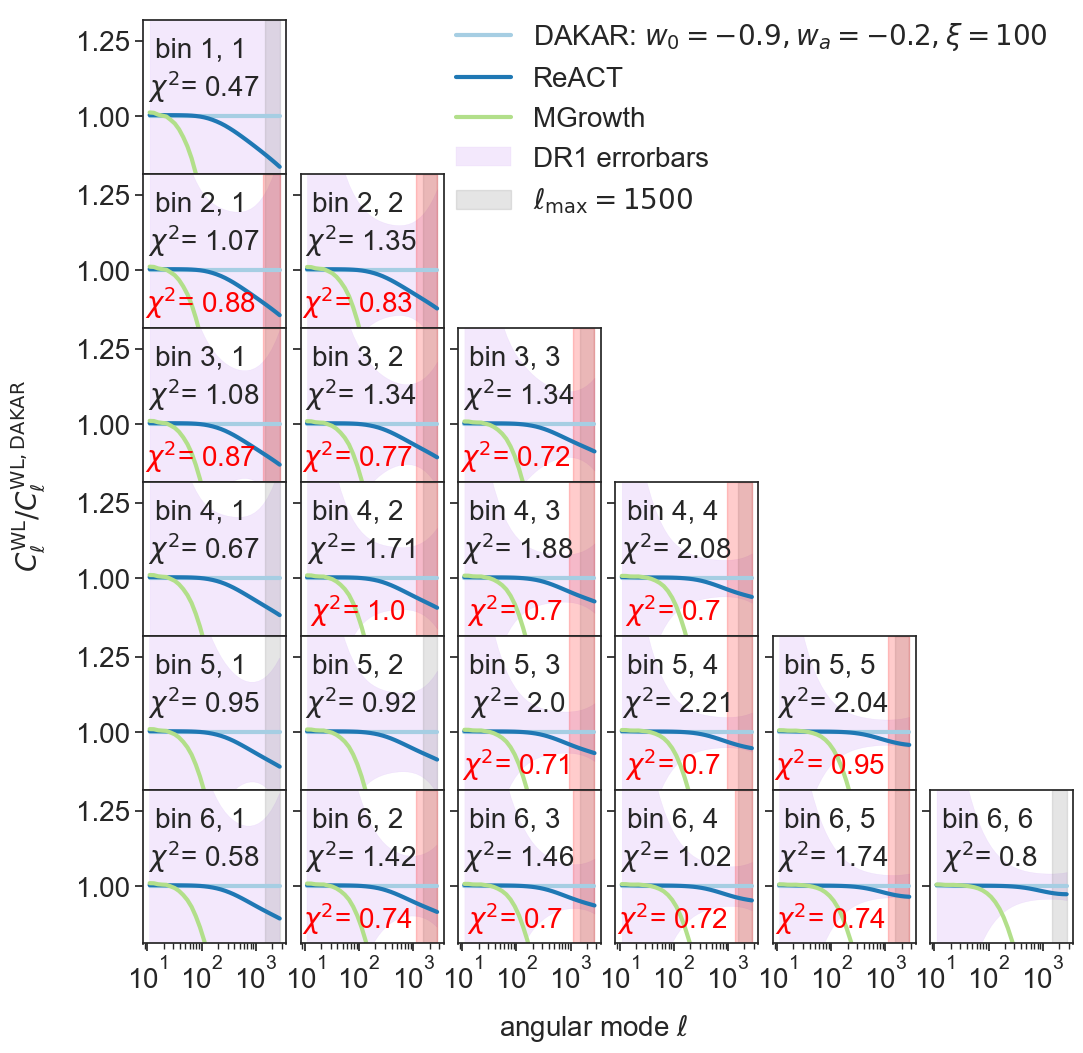

In [23]:
nbin = 6
nell = 32
chi2_lim = 1.
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            # find index of this pair
            p = pairs_wl.index((i, j))
            start = p * nell
            end = (p + 1) * nell
            err = errors_wl[start:end]/cells_wl['tab'][('SHE', 'SHE', j+1, i+1)][0, 0]
            for label in labels:
                y = cells_wl[label][('SHE', 'SHE', j+1, i+1)][0, 0]/cells_wl['tab'][('SHE', 'SHE', j+1, i+1)][0, 0]
                ax[i,j].semilogx(ell_theory,  y)
                if label == 'react':
                    diff = cells_wl[label][('SHE', 'SHE', j+1, i+1)][0, 0]-cells_wl['tab'][('SHE', 'SHE', j+1, i+1)][0, 0]
                    mask = ell_theory<1500
                    chi2 = np.sum(diff[mask]**2/errors_wl[start:end][mask]**2)
                    n = 1
                    chi2_new = chi2
                    if chi2>chi2_lim:
                        while chi2_new>chi2_lim:
                            mask_new = ell_theory < (1500 - n*10)
                            chi2_new = np.sum(diff[mask_new]**2/errors_wl[start:end][mask_new]**2)
                            #print(i, j, chi2_new, (1500 - n*10))
                            n +=1

                            
            
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .5, 'bin %s, %s\n $\\chi^2$= %s'%(str(i+1),(j+1), round(chi2, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            #ax[i, j].axvspan(xmin=200, xmax=ell_theory[-1], color='grey', alpha=0.1)
            #ax[i, j].axvspan(xmin=500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            ax[i, j].axvspan(xmin=1500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            ax[i, j].set_ylim(0.81, 1.32)
            #print('bin: ', i+1, j+1, 'chi2=', chi2)
            if chi2_new != chi2:
                ax[i,j].text(.4, .1, '$\\chi^2$= %s'%(round(chi2_new, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes, color='red')
                ax[i, j].axvspan(xmin=1500 - (n-1)*10, xmax=ell_theory[-1], color='red', alpha=0.2, label='$\\chi^2<2$')
                print('bin ', j+1, i+1, 'new lmax = ', 1500 - (n-1)*10)
                
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm WL}_{\ell}/C^{\rm WL, DAKAR}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels_names+['DR1 errorbars', '$\\ell_{\\rm max}=1500$'],  loc='upper right', ncol=1, bbox_to_anchor=(0.9, 0.9), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
#plt.savefig('figures/dakartest_ds_shear.png', dpi=300, bbox_inches='tight')

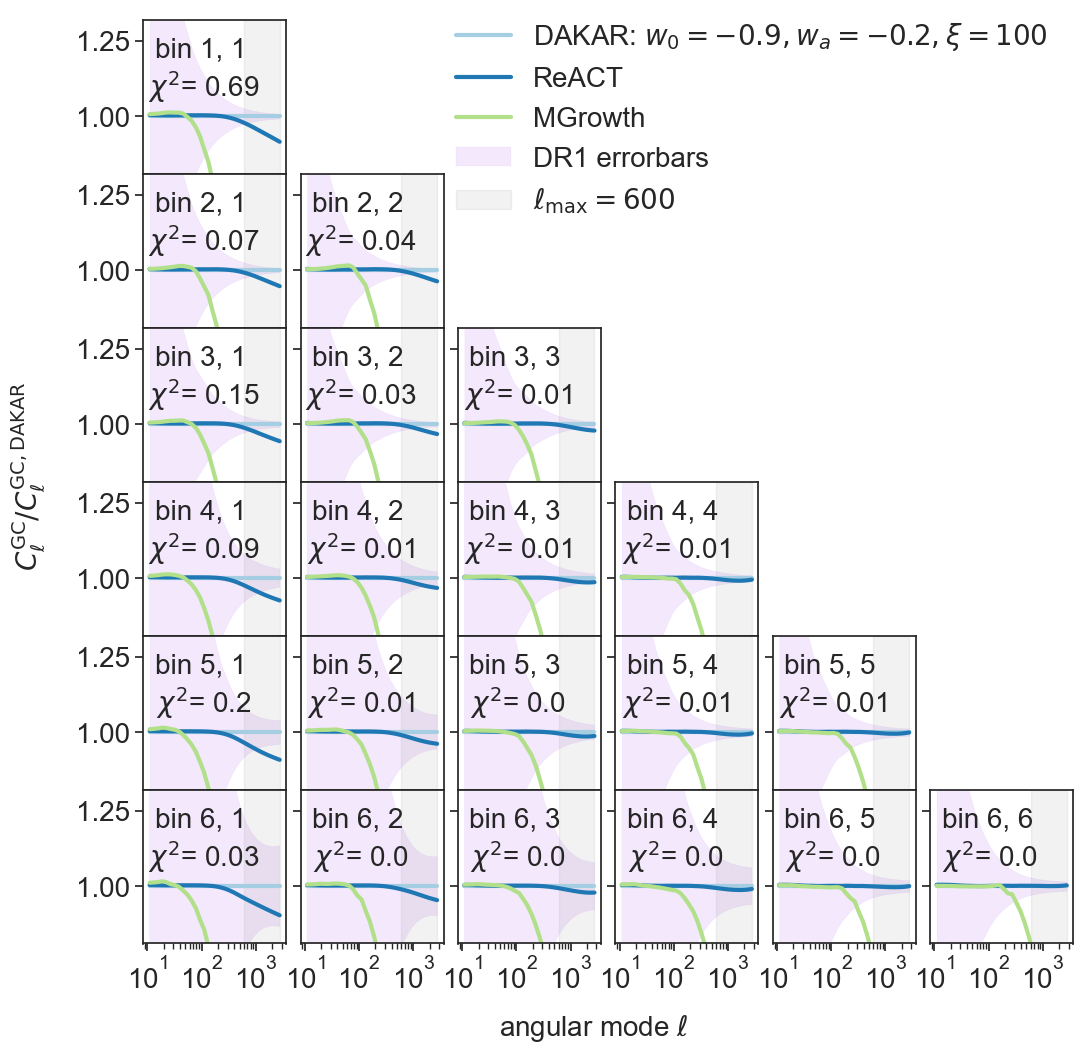

In [24]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
        if i >= j:
            # find index of this pair
            p = pairs_gc.index((i, j))
            
            start = p * nell
            end = (p + 1) * nell
            err = errors_gc[start:end]/cells_gc['tab'][('POS', 'POS', j+1, i+1)][:]
            for label in labels:
                y = cells_gc[label][('POS', 'POS', j+1, i+1)][:]/cells_gc['tab'][('POS', 'POS', j+1, i+1)][:]
                ax[i,j].semilogx(ell_theory,  y)
                if label == 'react':
                    diff = cells_gc[label][('POS', 'POS', j+1, i+1)][:]-cells_gc['tab'][('POS', 'POS', j+1, i+1)][:]
                    mask = ell_theory<600
                    chi2 = np.sum(diff[mask]**2/errors_gc[start:end][mask]**2)
            
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .5, 'bin %s, %s\n $\\chi^2$= %s'%(str(i+1),(j+1), round(chi2, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=600, xmax=ell_theory[-1], color='grey', alpha=0.1)
            #ax[i, j].axvspan(xmin=500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            #ax[i, j].axvspan(xmin=1500, xmax=ell_theory[-1], color='grey', alpha=0.5)
            ax[i, j].set_ylim(0.81, 1.32)
        else:
            ax[i,j].axis('off')       
fig.text(0.03, 0.5, r'$C^{\rm GC}_{\ell}/C^{\rm GC, DAKAR}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)   
fig.legend(labels_names+['DR1 errorbars', '$\\ell_{\\rm max}=600$'],  loc='upper right', ncol=1, bbox_to_anchor=(0.9, 0.9), bbox_transform=fig.transFigure, fontsize=20, frameon=False, title_fontsize=20)
#plt.savefig('figures/dakartest_ds_gclustering.png', dpi=300, bbox_inches='tight')

Text(0.5, 0.04, 'angular mode $\\ell$')

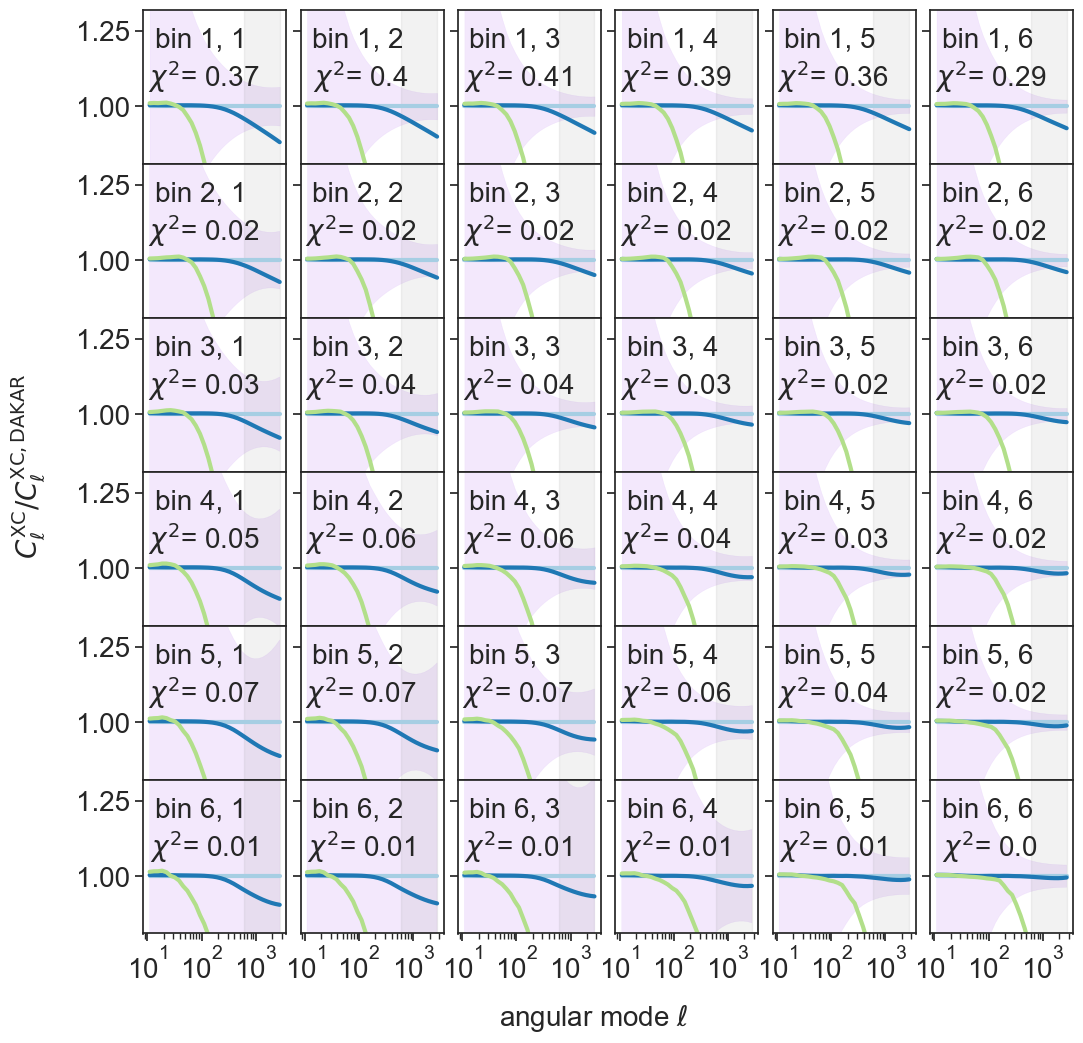

In [25]:
fig, ax = plt.subplots(nbin, nbin, figsize=(12, 12), sharey='row', sharex=True, gridspec_kw={'wspace': 0.1, 'hspace': 0})
for i in range(nbin):
    for j in range(nbin):
            # find index of this pair
            p = pairs_ggl.index((i, j))
            
            start = p * nell
            end = (p + 1) * nell
            err = errors_ggl[start:end]/cells_ggl['tab'][('POS', 'SHE', i+1, j+1)][0]
            for label in labels:
                y = cells_ggl[label][('POS', 'SHE', i+1, j+1)][0]/cells_ggl['tab'][('POS', 'SHE', i+1, j+1)][0]
                ax[i,j].semilogx(ell_theory,  y)
                if label == 'react':
                    diff = cells_ggl[label][('POS', 'SHE', i+1, j+1)][0]-cells_ggl['tab'][('POS', 'SHE', i+1, j+1)][0]
                    mask = ell_theory<600
                    chi2 = np.sum(diff[mask]**2/errors_ggl[start:end][mask]**2)
            
            # shaded region
            ax[i,j].fill_between(
                    ell_theory,
                    1. - err,
                    1. + err,
                    color='#d8b4f8',
                    alpha=0.3,
                    linewidth=0.3
                )

            ax[i,j].text(.4, .5, 'bin %s, %s\n $\\chi^2$= %s'%(str(i+1),(j+1), round(chi2, 2)), fontsize="medium", horizontalalignment='center', transform=ax[i,j].transAxes)
            ax[i, j].axvspan(xmin=600, xmax=ell_theory[-1], color='grey', alpha=0.1)
            #ax[i, j].axvspan(xmin=500, xmax=ell_theory[-1], color='grey', alpha=0.2)
            #ax[i, j].axvspan(xmin=1500, xmax=ell_theory[-1], color='grey', alpha=0.5)
            ax[i, j].set_ylim(0.81, 1.32)      
fig.text(0.03, 0.5, r'$C^{\rm XC}_{\ell}/C^{\rm XC, DAKAR}_{\ell}$', ha='center', va='center', rotation='vertical', fontsize=20)
fig.text(0.5, 0.04, r'angular mode $\ell$', ha='center', va='center', fontsize=20)  
#plt.savefig('figures/dakartest_ds_cross.png', dpi=300, bbox_inches='tight')